# 00 — The NMDC Landscape in BERDL

**Project:** nmdc_context_audit · **Author:** Mark Andrew Miller (LBL, ORCID 0000-0001-9076-6066)

Reproducible consolidation of every "NMDC"-labeled resource in BERDL: provenance class,
scale (row counts via Iceberg metadata), and data currency (latest Iceberg snapshot).
Every claim in the `knowledge/` directory traces back to a cell here.

Run on-cluster (BERDL JupyterHub). Outputs: `data/nmdc_landscape.csv`,
`figures/nmdc_currency.png`, `figures/nmdc_scale.png`.

In [1]:
import os, pandas as pd
from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()
os.makedirs("../data", exist_ok=True); os.makedirs("../figures", exist_ok=True)
print("Spark session ready")

Spark session ready


## 1. Enumerate every database whose name contains "nmdc"

The catalog exposes each tenant database under **two aliases** — dotted
(`nmdc.metadata`, an Iceberg catalog.namespace) and underscore
(`nmdc_metadata`, the underlying Hive table). We de-duplicate to the dotted form and
flag the aliases + cruft explicitly.

In [2]:
import berdl_notebook_utils as bnu
all_dbs = bnu.get_databases(return_json=False)
nmdc_dbs = sorted(d for d in all_dbs if "nmdc" in d.lower())
for d in nmdc_dbs: print(d)

globalusers.nmdc_core_test3
globalusers.nmdc_core_test4
globalusers_nmdc_core_test
globalusers_nmdc_core_test2
globalusers_nmdc_core_test3
globalusers_nmdc_core_test4
kbase.nmdc_arkin
kbase.nmdc_mags
kbase.nmdc_neon
kbase_nmdc_neon
mamillerpa.nmdc_flattened_biosamples
my.nmdc_flattened_biosamples
nmdc.metadata
nmdc.ncbi_biosamples
nmdc.ref_data
nmdc.results
nmdc_metadata
nmdc_ncbi_biosamples
nmdc_ref_data
nmdc_results


## 2. Provenance / scale / currency of every *real* resource

Signature tables per database. Row counts use Iceberg metadata (cheap even at 10^9).
Currency = `max(committed_at)` from the Iceberg `.snapshots` metadata table.

In [3]:
LANDSCAPE = [
    # (resource, tenant, provenance_class, db, signature_table, authority)
    ("nmdc.metadata",        "nmdc",  "Genuine NMDC",           "nmdc.metadata",        "biosample_set",              "microbiomedata.org"),
    ("nmdc.results",         "nmdc",  "Genuine NMDC",           "nmdc.results",         "annotation_kegg_orthology",  "microbiomedata.org"),
    ("nmdc.ncbi_biosamples", "nmdc",  "External (NCBI re-host)","nmdc.ncbi_biosamples", "biosamples_flattened",       "ncbi.nlm.nih.gov/biosample"),
    ("nmdc.ref_data",        "nmdc",  "External (Pfam re-host)","nmdc.ref_data",        "pfam_terms",                 "pfam.xfam.org"),
    ("kbase.nmdc_arkin",     "kbase", "Arkin-lab derivation",   "kbase.nmdc_arkin",     "taxonomy_dim",               "LBNL Arkin Lab"),
    ("kbase.nmdc_mags",      "kbase", "NMDC-derived (kbase)",   "kbase.nmdc_mags",      "mag_catalog",                "KBase / NMDC"),
    ("kbase.nmdc_neon",      "kbase", "Namesake (NEON program)","kbase.nmdc_neon",      "neon_mag_catalog",           "NEON (neonscience.org)"),
]

rows = []
for resource, tenant, pclass, db, tbl, auth in LANDSCAPE:
    fq = f"{db}.{tbl}"
    try:
        n = int(spark.sql(f"SELECT COUNT(*) c FROM {fq}").collect()[0]["c"])
    except Exception as e:
        n = None; print("count err", fq, str(e)[:60])
    try:
        c = str(spark.sql(f"SELECT max(committed_at) m FROM {fq}.snapshots").collect()[0]["m"])
    except Exception:
        c = None
    rows.append(dict(resource=resource, tenant=tenant, provenance_class=pclass,
                     example_table=tbl, rows=n, last_commit=c, authority=auth))

land = pd.DataFrame(rows)
land

,resource,tenant,provenance_class,example_table,rows,last_commit,authority
0,nmdc.metadata,nmdc,Genuine NMDC,biosample_set,16640,2026-05-20 01:15:48.857000,microbiomedata.org
1,nmdc.results,nmdc,Genuine NMDC,annotation_kegg_orthology,1831998811,2026-05-20 01:31:46.032000,microbiomedata.org
2,nmdc.ncbi_biosamples,nmdc,External (NCBI re-host),biosamples_flattened,51711888,2026-03-09 03:58:35.218000,ncbi.nlm.nih.gov/biosample
3,nmdc.ref_data,nmdc,External (Pfam re-host),pfam_terms,27481,2026-05-20 01:17:47.112000,pfam.xfam.org
4,kbase.nmdc_arkin,kbase,Arkin-lab derivation,taxonomy_dim,2594787,2026-05-27 04:10:34.181000,LBNL Arkin Lab
5,kbase.nmdc_mags,kbase,NMDC-derived (kbase),mag_catalog,62346,2026-07-02 16:09:49.338000,KBase / NMDC
6,kbase.nmdc_neon,kbase,Namesake (NEON program),neon_mag_catalog,16093,2026-07-02 16:06:07.593000,NEON (neonscience.org)


## 3. Catalogue the aliases and cruft (facts, not counted)

These are the naming hazards a user meets during discovery.

In [4]:
cruft = pd.DataFrame([
    dict(item="dual aliases", detail="every tenant DB is exposed as BOTH nmdc.metadata and nmdc_metadata (Iceberg vs Hive)"),
    dict(item="kbase.nmdc_* split home", detail="nmdc_arkin/nmdc_mags/nmdc_neon live in the kbase tenant; inventory groups them under 'kbase'"),
    dict(item="globalusers.nmdc_core_test3/4", detail="test databases (covstats_gold) named nmdc; not real NMDC data"),
    dict(item="phantom kbase_nmdc_neon", detail="underscore alias resolves to 0 tables"),
    dict(item="broken user copies", detail="mamillerpa/my.nmdc_flattened_biosamples: Iceberg metadata pointer missing (BadRequestException)"),
])
cruft

,item,detail
0,dual aliases,every tenant DB is exposed as BOTH nmdc.metada...
1,kbase.nmdc_* split home,nmdc_arkin/nmdc_mags/nmdc_neon live in the kba...
2,globalusers.nmdc_core_test3/4,test databases (covstats_gold) named nmdc; not...
3,phantom kbase_nmdc_neon,underscore alias resolves to 0 tables
4,broken user copies,mamillerpa/my.nmdc_flattened_biosamples: Icebe...


## 4. Persist the landscape table

In [5]:
land.to_csv("../data/nmdc_landscape.csv", index=False)
cruft.to_csv("../data/nmdc_naming_cruft.csv", index=False)
print("wrote data/nmdc_landscape.csv and data/nmdc_naming_cruft.csv")
print(land.to_string(index=False))

wrote data/nmdc_landscape.csv and data/nmdc_naming_cruft.csv
            resource tenant        provenance_class             example_table       rows                last_commit                  authority
       nmdc.metadata   nmdc            Genuine NMDC             biosample_set      16640 2026-05-20 01:15:48.857000         microbiomedata.org
        nmdc.results   nmdc            Genuine NMDC annotation_kegg_orthology 1831998811 2026-05-20 01:31:46.032000         microbiomedata.org
nmdc.ncbi_biosamples   nmdc External (NCBI re-host)      biosamples_flattened   51711888 2026-03-09 03:58:35.218000 ncbi.nlm.nih.gov/biosample
       nmdc.ref_data   nmdc External (Pfam re-host)                pfam_terms      27481 2026-05-20 01:17:47.112000              pfam.xfam.org
    kbase.nmdc_arkin  kbase    Arkin-lab derivation              taxonomy_dim    2594787 2026-05-27 04:10:34.181000             LBNL Arkin Lab
     kbase.nmdc_mags  kbase    NMDC-derived (kbase)               mag_catalog    

## 5. Figures — currency and scale by provenance class

The two axes a BERIL user needs but cannot see today: *how fresh* and *how big*, colored
by *what it actually is*.

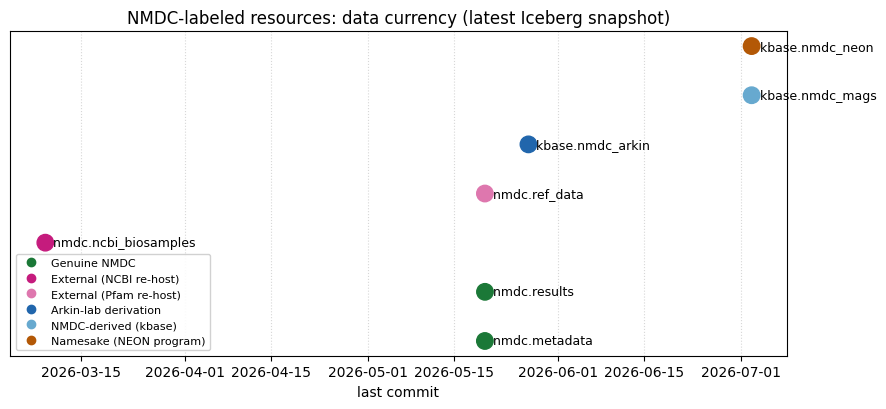

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd, numpy as np

d = land.dropna(subset=["last_commit"]).copy()
d["dt"] = pd.to_datetime(d["last_commit"])
palette = {
    "Genuine NMDC": "#1b7837",
    "External (NCBI re-host)": "#c51b7d",
    "External (Pfam re-host)": "#de77ae",
    "Arkin-lab derivation": "#2166ac",
    "NMDC-derived (kbase)": "#67a9cf",
    "Namesake (NEON program)": "#b35806",
}
colors = d["provenance_class"].map(palette)

fig, ax = plt.subplots(figsize=(9,4.2))
ax.scatter(d["dt"], range(len(d)), c=colors, s=140, zorder=3)
for i,(_,r) in enumerate(d.iterrows()):
    ax.text(r["dt"], i, "  "+r["resource"], va="center", fontsize=9)
ax.set_yticks([]); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.set_title("NMDC-labeled resources: data currency (latest Iceberg snapshot)")
ax.set_xlabel("last commit"); ax.grid(axis="x", ls=":", alpha=.5)
handles=[plt.Line2D([0],[0],marker="o",ls="",mfc=c,mec=c,label=k) for k,c in palette.items() if k in set(d["provenance_class"])]
ax.legend(handles=handles, fontsize=8, loc="lower left", framealpha=.9)
plt.tight_layout(); plt.savefig("../figures/nmdc_currency.png", dpi=140); plt.show()

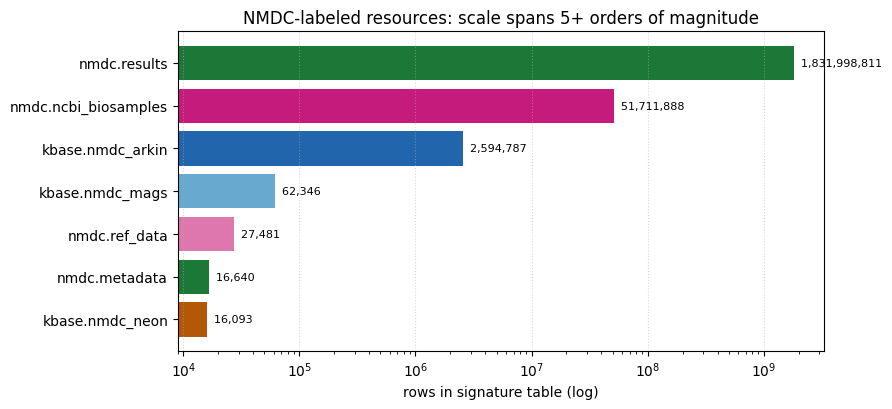

In [7]:
d2 = land.dropna(subset=["rows"]).copy().sort_values("rows")
fig, ax = plt.subplots(figsize=(9,4.2))
ax.barh(d2["resource"], d2["rows"], color=d2["provenance_class"].map(palette))
ax.set_xscale("log"); ax.set_xlabel("rows in signature table (log)")
ax.set_title("NMDC-labeled resources: scale spans 5+ orders of magnitude")
for i,(_,r) in enumerate(d2.iterrows()):
    ax.text(r["rows"], i, f"  {int(r['rows']):,}", va="center", fontsize=8)
ax.grid(axis="x", ls=":", alpha=.5)
plt.tight_layout(); plt.savefig("../figures/nmdc_scale.png", dpi=140); plt.show()

## 6. Takeaways

- One label, **three tenants** (`nmdc`, `kbase`, plus broken user copies) and **six+
  provenance classes** including external NCBI/Pfam re-hosts and a NEON namesake.
- Scale spans **10^1 → 10^9** rows; currency spans **months**. Neither is visible at
  discovery time — no table `Comment`, no schema doc, no skill module.
- These facts are captured as an Open-Knowledge-Format directory in `../knowledge/`.